# Tutorial 3: Make way for MOANA (Multi Ordination ANAlysis, that is)

## Interacting with multiple phytoplankton groups simultaneously

MOANA is the first phytoplankton community composition algorithm to be released by PACE. This product returns near-surface concentrations (cells mL-1) of three different picophytoplankton (i.e., phytoplankton <2 μm in size): Prochlorococcus, Synechococcus, and autotrophic picoeukaryotes (Figure 15). The algorithm uses empirical relationships between measured cell concentrations, in situ hyperspectral remote sensing reflectances, and sea surface temperatures. Details of this algorithm can be found in [Lange et al. (2020)](https://doi.org/10.1364/OE.398127).

Picophytoplankton are composed of the cyanobacteria Prochlorococcus (∼0.8 µm) and Synechococcus (∼1 µm), as well as picoeukaryotes, which combined are responsible for 50 to 90% of all primary production in open ocean ecosystems108 and contribute up to 30% of carbon export109 in these regions. Geographically, Prochlorococcus tends to inhabit warmer and mostly oligotrophic waters surrounded by Synechococcus patches along frontal boundaries. These fronts often reside at boundaries where phytoplankton communities start to transition to higher concentrations of larger eukaryotic cells, such as picoeukaryotes and nanoeukaryotic flagellates. Thus, identification of Prochlorococcus and Synechococcus distributions may be useful in identifying trophic boundaries in oceanic ecosystems110, in addition to providing insight into productivity, food web regimes, and carbon export.

By the end of this tutorial, you will have:

> 1. Created pretty maps of the three phytoplankton classes in MOANA
> 2. Plotted how all three of these phytoplankton classes change in relation to latitude
> 3. Plotted how all three of these phytoplankton classes change over the course of 1 year
> 4. Created a ternary plot and map that shows where each phytoplankton class dominates

## Are you ready?

In [2]:
# ---- Load Libraries ----
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# ---- Load Data ----
filename = 'PACE_OCI.20240901_20240930.L3m.MO.MOANA.V3_0.0p1deg.nc'
dataset = xr.open_dataset(filename)

# Assign core variables
latitude = dataset["lat"]
longitude = dataset["lon"]
syn_da = dataset["syncoccus_moana"]
pico_da = dataset["picoeuk_moana"]
pro_da = dataset["prococcus_moana"]

Create pretty maps of the three phytoplankton classes in MOANA

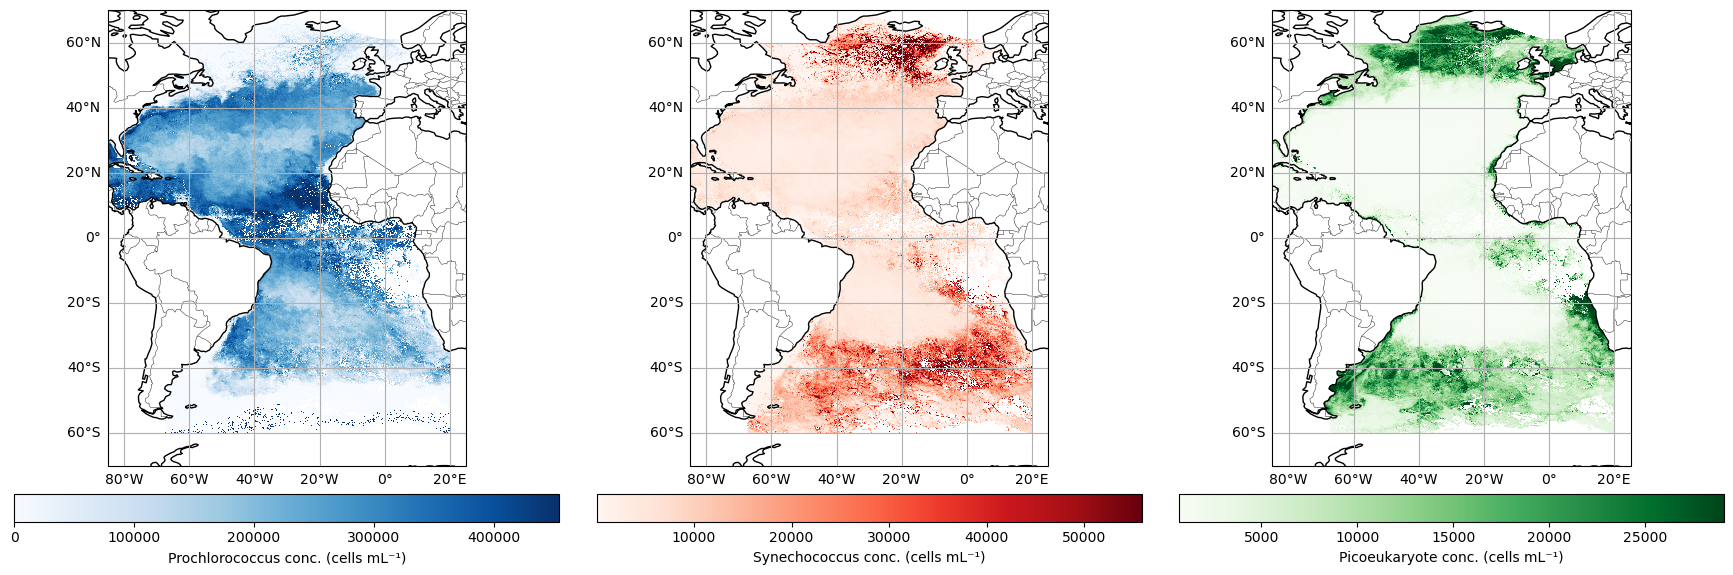

In [3]:
# Define colormaps
custom_cmaps = {
    "Prochlorococcus": plt.cm.Blues,
    "Synechococcus": plt.cm.Reds,
    "Picoeukaryotes": plt.cm.Greens
}

# Label text for colorbars
colorbar_labels = {
    "Prochlorococcus": "Prochlorococcus conc. (cells mL⁻¹)",
    "Synechococcus": "Synechococcus conc. (cells mL⁻¹)",
    "Picoeukaryotes": "Picoeukaryote conc. (cells mL⁻¹)"
}

# Set up figure and axes
fig, axs = plt.subplots(1, 3, figsize=(18, 6),
                        subplot_kw={'projection': ccrs.PlateCarree()})

phyto_list = [
    ("Prochlorococcus", pro_da, axs[0]),
    ("Synechococcus", syn_da, axs[1]),
    ("Picoeukaryotes", pico_da, axs[2])
]

for title, data, ax in phyto_list:
    ax.set_title(title)
    ax.coastlines()
    ax.add_feature(cfeature.BORDERS, linewidth=0.3)
    gl = ax.gridlines(draw_labels=True)
    gl.right_labels = gl.top_labels = False

    # Plot with custom ternary-style colormap and auto robust scaling
    cmap = custom_cmaps[title]
    img = data.plot(
        ax=ax,
        x="lon", y="lat",
        cmap=cmap,
        robust=True,
        add_colorbar=False
    )

    # Add custom colorbar label
    cbar = plt.colorbar(img, ax=ax, orientation='horizontal', pad=0.05, shrink=0.9)
    cbar.set_label(colorbar_labels[title])

plt.tight_layout()
plt.show()

Plot how all three of these phytoplankton classes change in relation to latitude

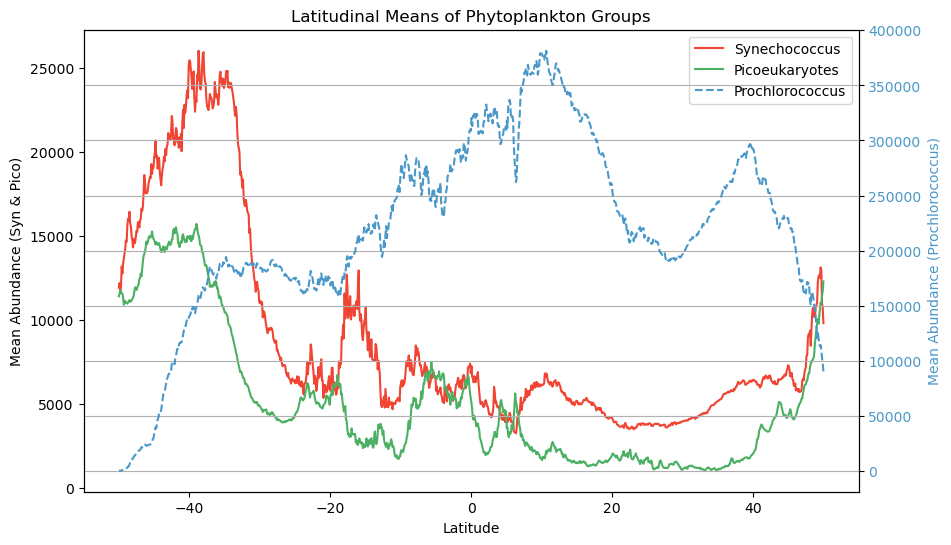

In [4]:
syn = dataset["syncoccus_moana"].sel(lat = slice(50, -50)).mean(dim=["lon"])
pro = dataset["prococcus_moana"].sel(lat = slice(50, -50)).mean(dim=["lon"])
pico = dataset["picoeuk_moana"].sel(lat = slice(50, -50)).mean(dim=["lon"])

custom_colors = {
    "Prochlorococcus": plt.cm.Blues(0.6),
    "Synechococcus": plt.cm.Reds(0.6),
    "Picoeukaryotes": plt.cm.Greens(0.6)
}

fig, ax1 = plt.subplots(figsize=(10, 6))

# Primary axis: Syn and Pico
ax1.plot(syn["lat"], syn, label="Synechococcus", color=custom_colors["Synechococcus"])
ax1.plot(pico["lat"], pico, label="Picoeukaryotes", color=custom_colors["Picoeukaryotes"])
ax1.set_xlabel("Latitude")
ax1.set_ylabel("Mean Abundance (Syn & Pico)", color="black")
ax1.tick_params(axis='y', labelcolor="black")

# Secondary axis: Prochlorococcus
ax2 = ax1.twinx()
ax2.plot(pro["lat"], pro, label="Prochlorococcus", color=custom_colors["Prochlorococcus"], linestyle="--")
ax2.set_ylabel("Mean Abundance (Prochlorococcus)", color=custom_colors["Prochlorococcus"])
ax2.tick_params(axis='y', labelcolor=custom_colors["Prochlorococcus"])

# Combine legends
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper right")

plt.title("Latitudinal Means of Phytoplankton Groups")
plt.grid(True)
plt.show()

Plot how all three of these phytoplankton classes change over the course of 1 year

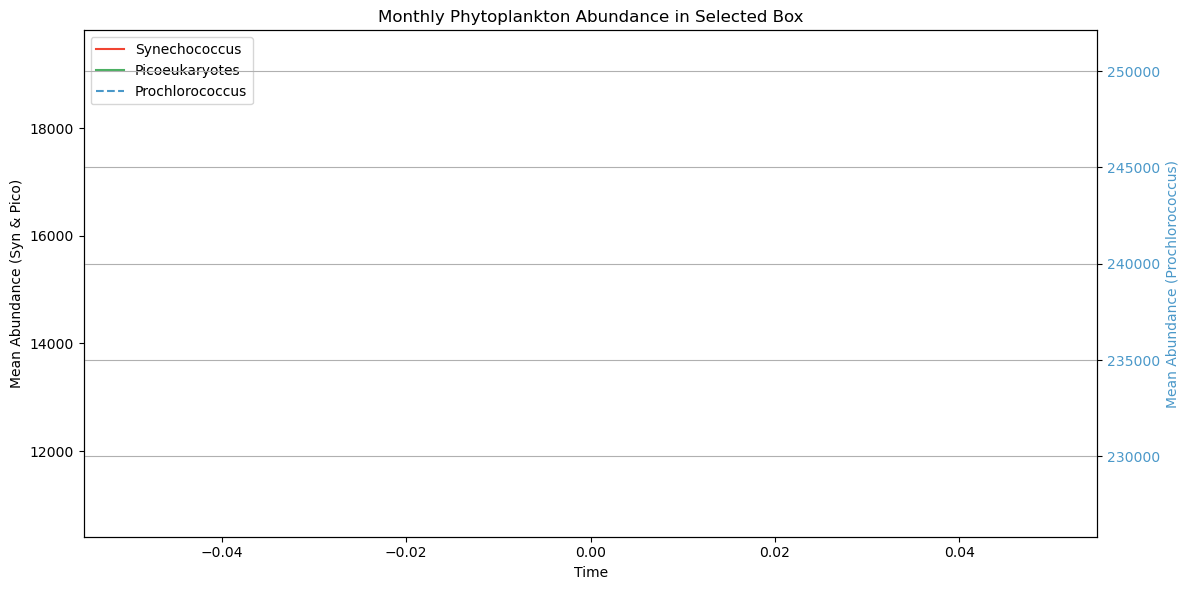

In [10]:
file_pattern = "PACE_OCI.202*.L3m.MO.MOANA.V3_0.0p1deg.nc"
ds = xr.open_mfdataset(file_pattern, combine='nested',concat_dim="time")

lat_box = slice(-30, -40)     # reversed order: north to south
lon_box = slice(-40, -30)     # within available lon range

# Subset and average over space (lat/lon)
syn_timeseries = ds["syncoccus_moana"].sel(lat=lat_box, lon=lon_box).mean(dim=["lat", "lon"], skipna=True)
pro_timeseries = ds["prococcus_moana"].sel(lat=lat_box, lon=lon_box).mean(dim=["lat", "lon"], skipna=True)
pico_timeseries = ds["picoeuk_moana"].sel(lat=lat_box, lon=lon_box).mean(dim=["lat", "lon"], skipna=True)

# Create the figure and axis
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot syn and pico on the left y-axis
ax1.plot(syn_timeseries["time"], syn_timeseries, label="Synechococcus", color=custom_colors["Synechococcus"])
ax1.plot(pico_timeseries["time"], pico_timeseries, label="Picoeukaryotes", color=custom_colors["Picoeukaryotes"])
ax1.set_xlabel("Time")
ax1.set_ylabel("Mean Abundance (Syn & Pico)", color="black")
ax1.tick_params(axis='y', labelcolor="black")

# Create a secondary y-axis for prococcus_moana
ax2 = ax1.twinx()
ax2.plot(pro_timeseries["time"], pro_timeseries, label="Prochlorococcus", color=custom_colors["Prochlorococcus"], linestyle="--")
ax2.set_ylabel("Mean Abundance (Prochlorococcus)", color=custom_colors["Prochlorococcus"])
ax2.tick_params(axis='y', labelcolor=custom_colors["Prochlorococcus"])

# Combine all legends
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper left")

# Add title and grid
plt.title("Monthly Phytoplankton Abundance in Selected Box")
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Created a ternary plot and map that shows where each phytoplankton class dominates

In [6]:
# ---- Normalize and Calculate Ternary Ratios ----
# Rename each DataArray to a common format and ensure coordinates are aligned
pro_da.name = "pro"
syn_da.name = "syn"
pico_da.name = "pico"

# Combine into a single dataset
ds_phyto = xr.Dataset({"pro": pro_da, "syn": syn_da, "pico": pico_da})

# Only keep ocean pixels (non-NaN in any of the three)
valid_mask = (pro_da.notnull()) & (syn_da.notnull()) & (pico_da.notnull())

# Apply mask
ds_phyto = xr.Dataset({
    "pro": pro_da.where(valid_mask),
    "syn": syn_da.where(valid_mask),
    "pico": pico_da.where(valid_mask),
})

# Robust normalization function (with skipna=True)
def robust_normalize(da, low=2, high=98):
    p_low = da.quantile(low / 100, dim=["lat", "lon"], skipna=True)
    p_high = da.quantile(high / 100, dim=["lat", "lon"], skipna=True)
    return ((da - p_low) / (p_high - p_low)).clip(0, 1)

# Apply to each phytoplankton type
ds_norm = xr.Dataset({
    "pro": robust_normalize(ds_phyto["pro"]),
    "syn": robust_normalize(ds_phyto["syn"]),
    "pico": robust_normalize(ds_phyto["pico"]),
})

# Ternary normalization (avoid divide-by-zero and fill land with NaN)
total = ds_norm["pro"] + ds_norm["syn"] + ds_norm["pico"]
ratios = xr.Dataset({
    "pro_ratio": ds_norm["pro"] / total,
    "syn_ratio": ds_norm["syn"] / total,
    "pico_ratio": ds_norm["pico"] / total,
}).where(total > 0)

In [7]:
# Extract ratios
pro_ratio = ratios["pro_ratio"]
syn_ratio = ratios["syn_ratio"]
pico_ratio = ratios["pico_ratio"]

# Stack into RGB array and clip to [0, 1]
rgb = xr.concat([syn_ratio, pico_ratio,pro_ratio], dim="band")
rgb = rgb.transpose("lat", "lon", "band").clip(0, 1).values
rgb_flipped = np.flipud(rgb)

ax.imshow(rgb_flipped, origin="upper",
          extent=[pro_da.lon.min(), pro_da.lon.max(),
                  pro_da.lat.min(), pro_da.lat.max()],
          transform=ccrs.PlateCarree())

# Optional: overlay landmask if you want a clearer coastline
ax.coastlines()

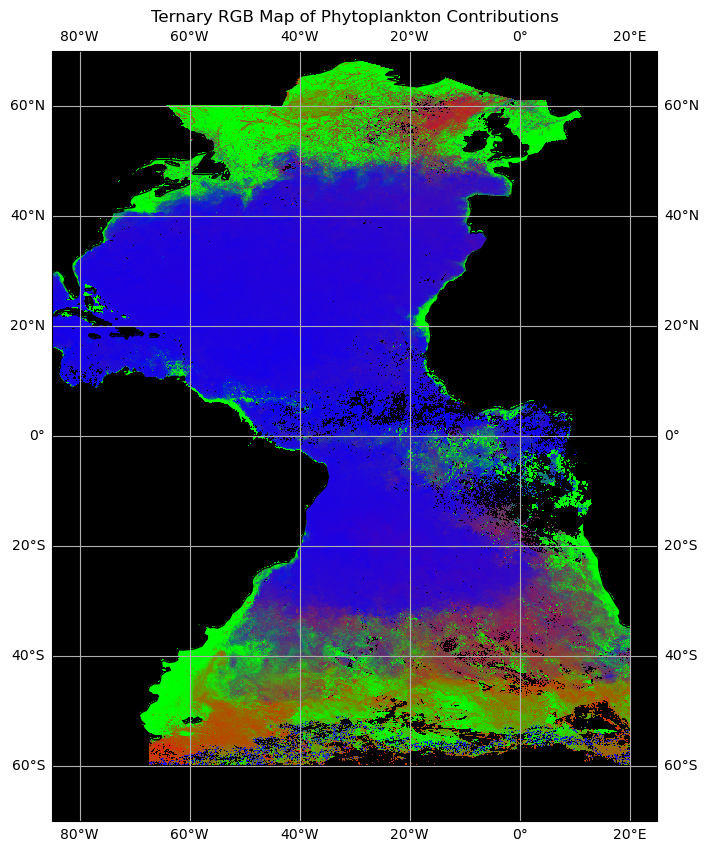

In [8]:
fig = plt.figure(figsize=(8, 10))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.coastlines()
ax.gridlines(draw_labels=True)

# Plot with 2D lat/lon support
ax.pcolormesh(
    longitude, latitude, rgb[..., 0],  # use R channel just to test alignment first
    color=rgb.reshape(-1, 3), shading="auto", transform=ccrs.PlateCarree()
)

plt.title("Ternary RGB Map of Phytoplankton Contributions")
plt.show()

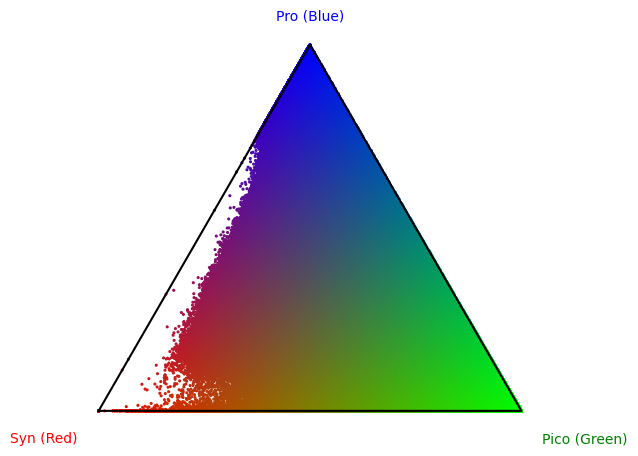

In [9]:
def ternary_axes_background(ax, scale=1.0):
    # Draw the triangle
    triangle = np.array([
        [0, 0],  # Bottom-left (Red)
        [scale, 0],  # Bottom-right (Green)
        [scale / 2, scale * np.sqrt(3) / 2],  # Top (Blue)
        [0, 0]  # Close the triangle
    ])
    ax.plot(triangle[:, 0], triangle[:, 1], color='k')
    ax.set_aspect('equal')
    ax.axis('off')

    # Optional labels
    ax.text(-0.05, -0.05, 'Syn (Red)', color='red', ha='right', va='top')
    ax.text(scale + 0.05, -0.05, 'Pico (Green)', color='green', ha='left', va='top')
    ax.text(scale/2, scale*np.sqrt(3)/2 + 0.05, 'Pro (Blue)', color='blue', ha='center', va='bottom')

def ternary_coords(pro, syn, pico):
    """Convert ternary (three-component) ratios to 2D triangle coordinates."""
    total = pro + syn + pico
    pro, syn, pico = pro / total, syn / total, pico / total
    x = 0.5 * (2 * syn + pico) / (pro + syn + pico)
    y = (np.sqrt(3) / 2) * pico / (pro + syn + pico)
    return x, y

# Flatten ratio arrays for plotting
flat_pro = pro_ratio.values.flatten()
flat_syn = syn_ratio.values.flatten()
flat_pico = pico_ratio.values.flatten()

# Mask invalid values (e.g., nan or total=0)
valid_mask = np.isfinite(flat_pro + flat_syn + flat_pico) & ((flat_pro + flat_syn + flat_pico) > 0)
flat_pro = flat_pro[valid_mask]
flat_syn = flat_syn[valid_mask]
flat_pico = flat_pico[valid_mask]

# Get RGB values as well
flat_rgb = rgb.reshape(-1, 3)[valid_mask]

# Convert to 2D coords
x_coords, y_coords = ternary_coords(flat_syn,flat_pico,flat_pro)

# Plot ternary diagram
fig, ax = plt.subplots(figsize=(6, 6))
ternary_axes_background(ax)
ax.scatter(x_coords, y_coords, c=flat_rgb, s=5, edgecolor='none')
#plt.title("Ternary Plot of Phytoplankton Contributions")
plt.show()